# **Energy Demand Forecasting using Time-Series Deep Learning Models**

### Dataset Link: https://www.kaggle.com/datasets/pinuto/us-oil-and-gas-production-and-disposition-20152025

# Data Loading

In [1]:
# Step 1: Load and inspect the dataset
# Import required libraries
import pandas as pd
import numpy as np

# Load dataset
file_path = "OGORBcsv_cleaned.csv"
df = pd.read_csv(file_path)

# Display basic information
print("Dataset shape:", df.shape)
print("\nColumns in dataset:\n", df.columns.tolist())

# Display first few rows
print("\nPreview of dataset:")
print(df.head())

# Step 2: Check data types and missing values
print("\nData types:\n", df.dtypes)
print("\nMissing values (in %):\n", (df.isna().mean() * 100).round(2))

# Step 3: Convert date and volume columns
# Convert 'Production Date' to datetime format
df['Production Date'] = pd.to_datetime(df['Production Date'], errors='coerce')

# Convert 'Volume' to numeric (remove commas if needed)
df['Volume'] = df['Volume'].replace(',', '', regex=True)
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

# Step 4: Quick summary after cleaning
print("\nDate range:", df['Production Date'].min(), "to", df['Production Date'].max())
print("Unique states:", df['State'].nunique())
print("Unique commodities:", df['Commodity'].nunique())
print("Unique land classes:", df['Land Class'].nunique())
print("Unique disposition types:", df['Disposition Description'].nunique())

Dataset shape: (470830, 11)

Columns in dataset:
 ['Production Date', 'Land Class', 'Land Category', 'State', 'County', 'FIPS Code', 'Offshore Region', 'Commodity', 'Disposition Code', 'Disposition Description', 'Volume']

Preview of dataset:
  Production Date Land Class Land Category     State    County FIPS Code  \
0      01/01/2015    Federal      Offshore  Offshore  Offshore  Offshore   
1      01/01/2015    Federal      Offshore  Offshore  Offshore  Offshore   
2      01/01/2015    Federal      Offshore  Offshore  Offshore  Offshore   
3      01/01/2015    Federal      Offshore  Offshore  Offshore  Offshore   
4      01/01/2015    Federal      Offshore  Offshore  Offshore  Offshore   

    Offshore Region  Commodity  Disposition Code  \
0   Offshore Alaska  Gas (Mcf)                 1   
1     Offshore Gulf  Gas (Mcf)                 1   
2  Offshore Pacific  Gas (Mcf)                 1   
3     Offshore Gulf  Gas (Mcf)                 4   
4  Offshore Pacific  Gas (Mcf)          

# Data Preparation

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Convert data types
df['Production Date'] = pd.to_datetime(df['Production Date'], errors='coerce')
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

# Drop invalid rows
df = df.dropna(subset=['Production Date', 'Volume'])
df = df[df['Volume'] > 0]

# Create Month column
df['Month'] = df['Production Date'].values.astype('datetime64[M]')

# Aggregate monthly total production
monthly_df = df.groupby('Month')['Volume'].sum().reset_index()

# Create full monthly range
full_range = pd.date_range(
    start=monthly_df['Month'].min(),
    end=monthly_df['Month'].max(),
    freq='MS'
)

# Reindex to include missing months
monthly_df = (
    monthly_df
    .set_index('Month')
    .reindex(full_range)
    .fillna(0.0)
    .rename_axis('Month')
    .reset_index()
)

# Log transform AFTER reindexing
monthly_df['Log_Volume'] = np.log1p(monthly_df['Volume'])

# Train test split index
train_size = int(len(monthly_df) * 0.8)

# Scale using training data only
scaler = MinMaxScaler(feature_range=(0, 1))

monthly_df.loc[:train_size, 'Scaled_Volume'] = scaler.fit_transform(
    monthly_df.loc[:train_size, ['Log_Volume']]
)

monthly_df.loc[train_size:, 'Scaled_Volume'] = scaler.transform(
    monthly_df.loc[train_size:, ['Log_Volume']]
)

# Verify
print("Final dataset shape:", monthly_df.shape)
print(monthly_df.head())

# Sequence creation function
def create_sequences(data, lookback=24):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

# Create LSTM sequences
lookback = 24
values = monthly_df['Scaled_Volume'].values
X, y = create_sequences(values, lookback)

# Train test split
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Final dataset shape: (125, 4)
       Month     Volume  Log_Volume  Scaled_Volume
0 2015-01-01  504312296   20.038706       0.506637
1 2015-02-01  456279863   19.938617       0.177379
2 2015-03-01  498178213   20.026468       0.466379
3 2015-04-01  502162590   20.034435       0.492585
4 2015-05-01  510480374   20.050863       0.546628
X_train shape: (80, 24, 1)
X_test shape: (21, 24, 1)


# Exploratory Data Analysis (EDA)

Dataset shape: (161236, 12)
Missing values (in %):
 Production Date            0.0
Land Class                 0.0
Land Category              0.0
State                      0.0
County                     0.0
FIPS Code                  0.0
Offshore Region            0.0
Commodity                  0.0
Disposition Code           0.0
Disposition Description    0.0
Volume                     0.0
Month                      0.0
dtype: float64
Date range: 2015-01-01 00:00:00 to 2025-05-01 00:00:00


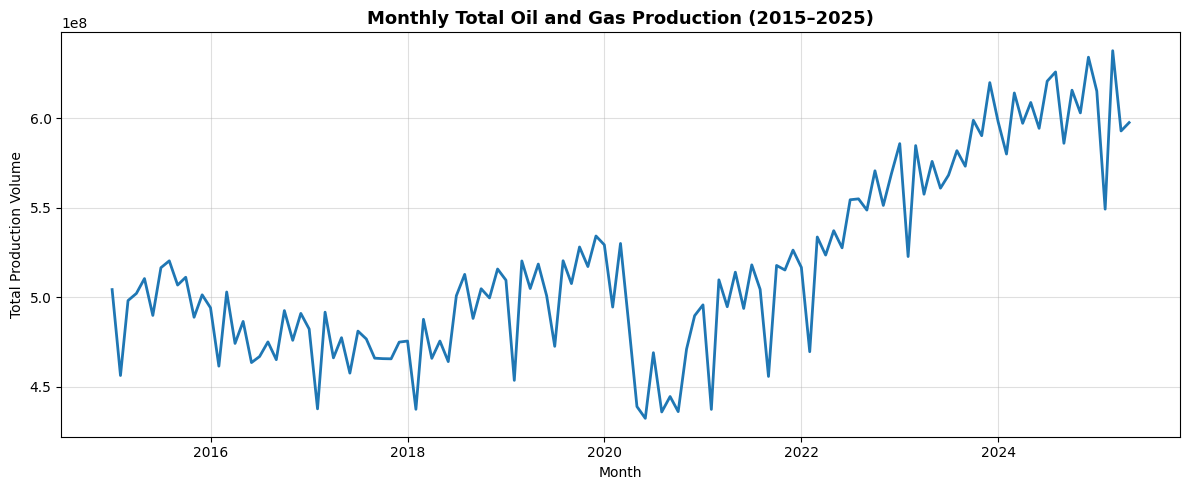

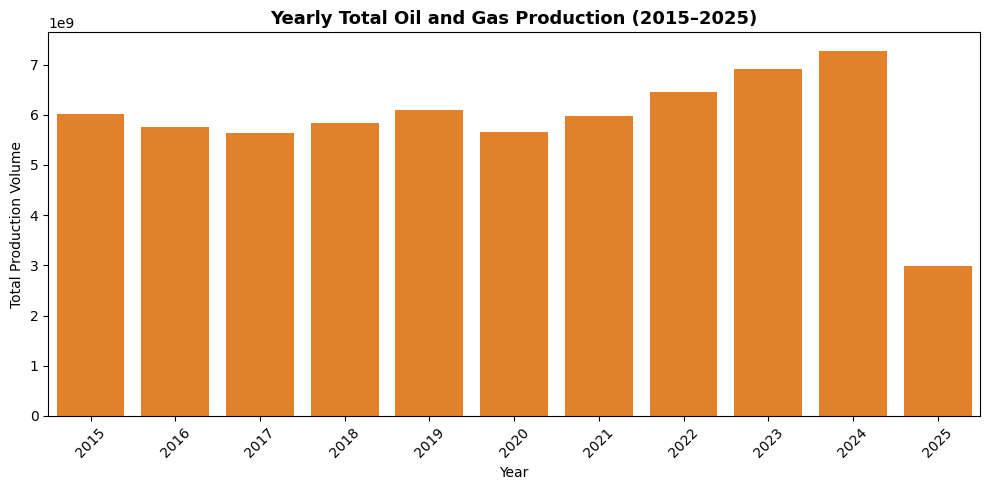

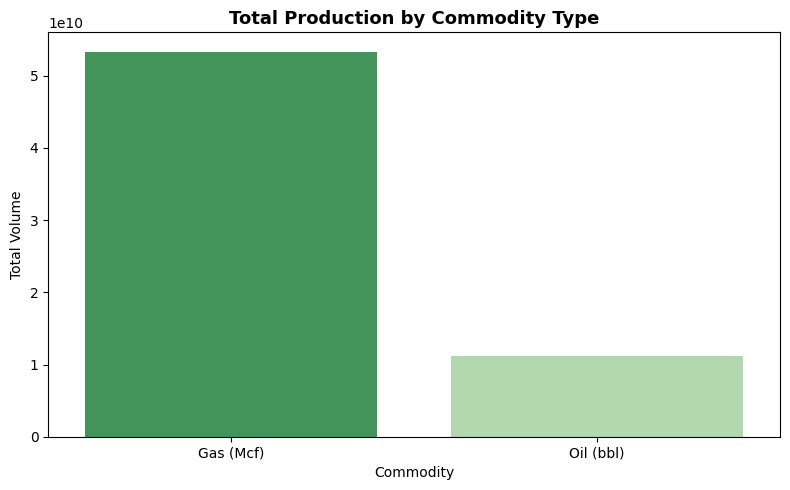

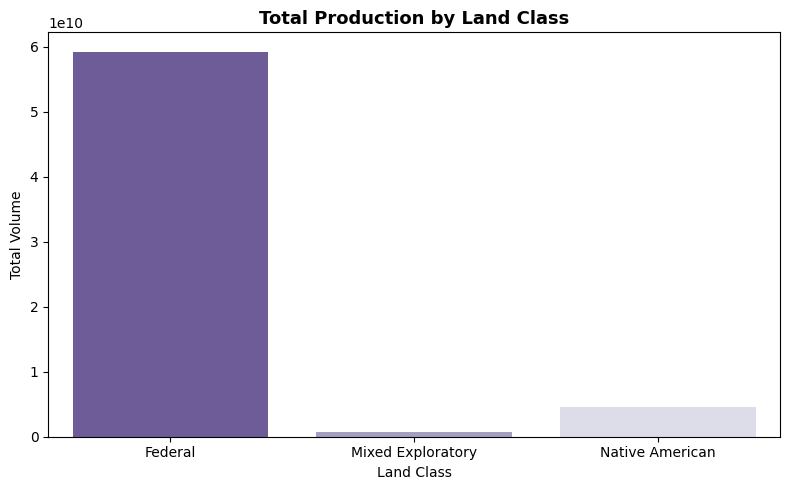

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Convert necessary columns
df['Production Date'] = pd.to_datetime(df['Production Date'], errors='coerce')
df['Volume'] = df['Volume'].replace(',', '', regex=True)
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

# Basic information
print("Dataset shape:", df.shape)
print("Missing values (in %):\n", (df.isna().mean() * 100).round(2))
print("Date range:", df['Production Date'].min(), "to", df['Production Date'].max())

# Create monthly and yearly aggregations
df['Month'] = df['Production Date'].values.astype('datetime64[M]')
df['Year'] = df['Production Date'].dt.year
monthly_df = df.groupby('Month')['Volume'].sum().reset_index()
yearly_df = df.groupby('Year')['Volume'].sum().reset_index()

# 1. Monthly total production trend (Blue theme)
plt.figure(figsize=(12, 5))
plt.plot(monthly_df['Month'], monthly_df['Volume'], color='#1f77b4', linewidth=2)
plt.title("Monthly Total Oil and Gas Production (2015–2025)", fontsize=13, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Total Production Volume")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# 2. Yearly total production trend (Orange theme)
plt.figure(figsize=(10, 5))
sns.barplot(x='Year', y='Volume', data=yearly_df, color='#ff7f0e')
plt.title("Yearly Total Oil and Gas Production (2015–2025)", fontsize=13, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Total Production Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Total production by commodity type (Green theme)
plt.figure(figsize=(8, 5))
commodity_df = df.groupby('Commodity')['Volume'].sum().reset_index()
sns.barplot(x='Commodity', y='Volume', data=commodity_df, palette='Greens_r')
plt.title("Total Production by Commodity Type", fontsize=13, fontweight='bold')
plt.xlabel("Commodity")
plt.ylabel("Total Volume")
plt.tight_layout()
plt.show()

# 4. Total production by land class (Purple theme)
plt.figure(figsize=(8, 5))
land_df = df.groupby('Land Class')['Volume'].sum().reset_index()
sns.barplot(x='Land Class', y='Volume', data=land_df, palette='Purples_r')
plt.title("Total Production by Land Class", fontsize=13, fontweight='bold')
plt.xlabel("Land Class")
plt.ylabel("Total Volume")
plt.tight_layout()
plt.show()

# Model Training

## Long Short-Term Memory (LSTM)

X_train shape (80, 24, 1)
X_test shape (21, 24, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 360ms/step - loss: 0.2076 - val_loss: 0.5610 - learning_rate: 0.0010
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.1394 - val_loss: 0.3785 - learning_rate: 0.0010
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0942 - val_loss: 0.2218 - learning_rate: 0.0010
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0624 - val_loss: 0.0982 - learning_rate: 0.0010
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0422 - val_loss: 0.0282 - learning_rate: 0.0010
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0490 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0527 - val_loss: 0.0150 - learning_rate: 0.0010
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0535 - val_loss: 0.0250 - learning_rate: 0.0010
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0460 - val_loss: 0.0431 - learning_rate: 0.0010
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━

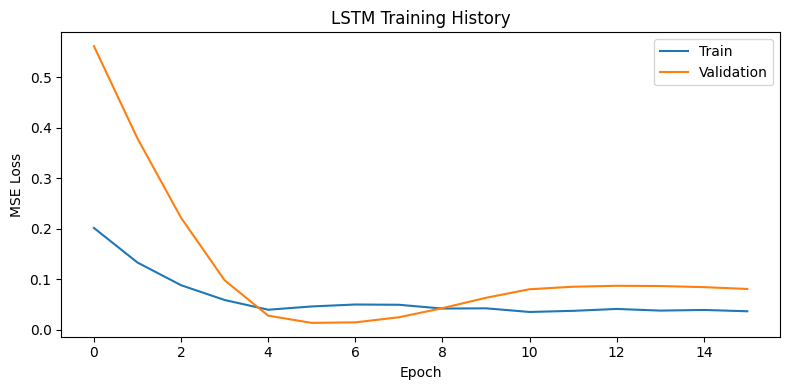

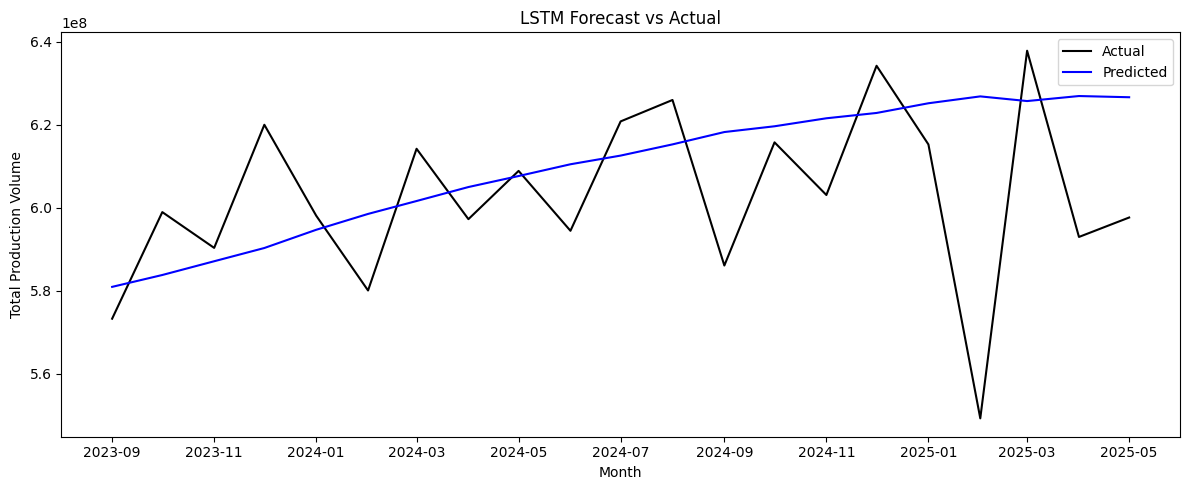

LSTM 3 Month Production Forecast
Forecast Month  Predicted Production Volume
      Jun 2025                  626654016.0
      Jul 2025                  627830080.0
      Aug 2025                  629403136.0


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Convert data types
df['Production Date'] = pd.to_datetime(df['Production Date'], errors='coerce')
df['Volume'] = df['Volume'].replace(',', '', regex=True)
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

# Remove invalid rows
df = df.dropna(subset=['Production Date', 'Volume'])
df = df[df['Volume'] > 0]

# Create Month column
df['Month'] = df['Production Date'].values.astype('datetime64[M]')

# Aggregate monthly totals
monthly_df = df.groupby('Month')['Volume'].sum().reset_index()

# Create full monthly range
full_range = pd.date_range(
    start=monthly_df['Month'].min(),
    end=monthly_df['Month'].max(),
    freq='MS'
)

# Reindex missing months
monthly_df = (
    monthly_df
    .set_index('Month')
    .reindex(full_range)
    .fillna(0.0)
    .rename_axis('Month')
    .reset_index()
)

# Log transformation
monthly_df['Log_Volume'] = np.log1p(monthly_df['Volume'])

# Train test split index
train_size = int(len(monthly_df) * 0.8)

# Scaling using training data only
scaler = MinMaxScaler(feature_range=(0, 1))

monthly_df.loc[:train_size, 'Scaled_Volume'] = scaler.fit_transform(
    monthly_df.loc[:train_size, ['Log_Volume']]
)

monthly_df.loc[train_size:, 'Scaled_Volume'] = scaler.transform(
    monthly_df.loc[train_size:, ['Log_Volume']]
)

# Sequence creation
def create_sequences(data, lookback=24):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)

lookback = 24
values = monthly_df['Scaled_Volume'].values
X, y = create_sequences(values, lookback)

# Train test split
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train shape", X_train.shape)
print("X_test shape", X_test.shape)

# Build LSTM model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1], 1)),
    layers.LSTM(64, activation='tanh'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

model.summary()

# Callbacks
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Predict on test set
y_pred_scaled = model.predict(X_test).ravel()

# Inverse scaling and log transform
y_test_log = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_log = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))

y_test_inv = np.expm1(y_test_log).ravel()
y_pred_inv = np.expm1(y_pred_log).ravel()

# Evaluation metrics in log scale
rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
mae_log = mean_absolute_error(y_test_log, y_pred_log)
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / np.clip(np.abs(y_test_inv), 1e-8, None))) * 100
accuracy = 100 - mape

print("\nLSTM Model Performance Summary:")
print(f"RMSE {rmse_log:.4f}")
print(f"MAE {mae_log:.4f}")
print(f"MAPE {mape:.2f}%")
print(f"Accuracy {accuracy:.2f}%")

# Plot training history
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training History')
plt.legend()
plt.tight_layout()
plt.show()

# Plot actual vs predicted
test_months = monthly_df['Month'].iloc[-len(y_test_inv):].reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(test_months, y_test_inv, label='Actual', color='black')
plt.plot(test_months, y_pred_inv, label='Predicted', color='blue')
plt.xlabel('Month')
plt.ylabel('Total Production Volume')
plt.title('LSTM Forecast vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

# Recursive forecasting
def recursive_forecast(model, scaler, last_sequence, steps, last_date):
    seq = last_sequence.copy()
    preds = []

    for _ in range(steps):
        pred_scaled = model.predict(seq[np.newaxis, :, :], verbose=0)[0, 0]
        preds.append(pred_scaled)
        seq = np.vstack([seq[1:], [[pred_scaled]]])

    preds_log = scaler.inverse_transform(np.array(preds).reshape(-1, 1))
    preds_inv = np.expm1(preds_log).ravel()

    future_dates = pd.date_range(
        start=last_date + pd.offsets.MonthBegin(1),
        periods=steps,
        freq='MS'
    )

    return pd.DataFrame({
        'Forecast Month': future_dates.strftime('%b %Y'),
        'Predicted Production Volume': np.round(preds_inv, 2)
    })

# Generate 3 month forecast
last_date = monthly_df['Month'].max()
forecast_df = recursive_forecast(
    model,
    scaler,
    last_sequence=X_test[-1],
    steps=3,
    last_date=last_date
)

print("LSTM 3 Month Production Forecast")
print(forecast_df.to_string(index=False))

## Seasonal Autoregressive Integrated Moving Average (SARIMA)

Training range 2015-01-01 00:00:00 to 2023-04-01 00:00:00
Testing range 2023-05-01 00:00:00 to 2025-05-01 00:00:00

SARIMA Model Performance Summary:
RMSE 0.0616
MAE 0.0580
MAPE 5.61%
Accuracy 94.39%


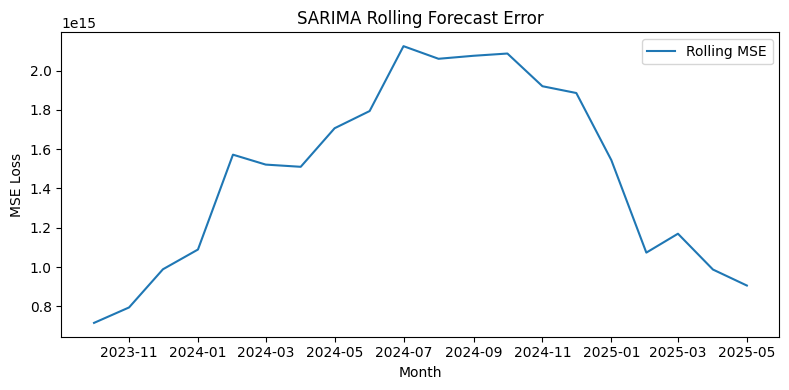

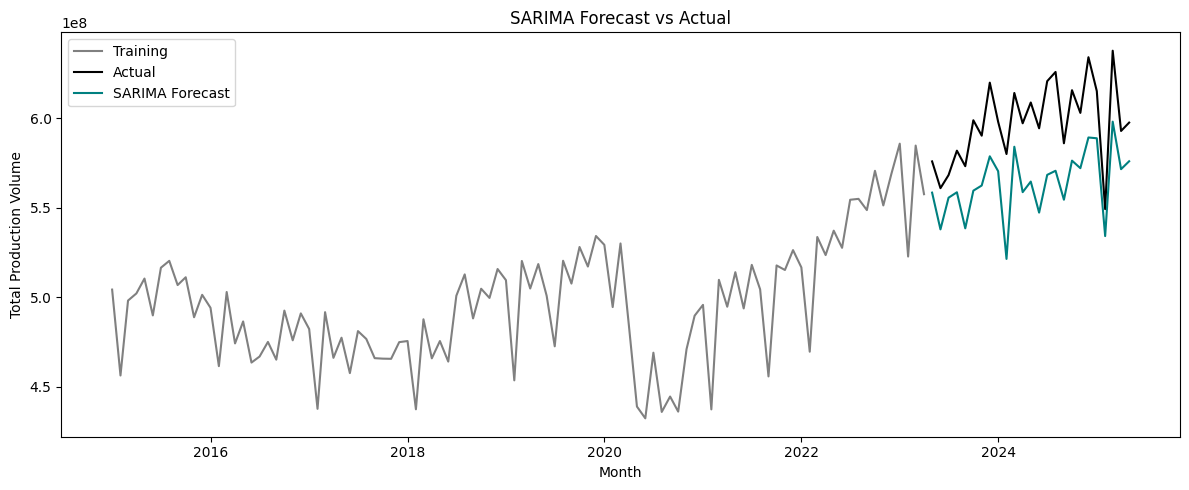


SARIMA 3 Month Production Forecast
Forecast Month  Predicted Production Volume
      Jun 2025                 558515610.45
      Jul 2025                 537974055.35
      Aug 2025                 555678106.19


In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Convert data types
df['Production Date'] = pd.to_datetime(df['Production Date'], errors='coerce')
df['Volume'] = df['Volume'].replace(',', '', regex=True)
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

# Remove invalid rows
df = df.dropna(subset=['Production Date', 'Volume'])
df = df[df['Volume'] > 0]

# Create Month column
df['Month'] = df['Production Date'].values.astype('datetime64[M]')

# Aggregate monthly totals
monthly_df = df.groupby('Month')['Volume'].sum().reset_index()

# Create full monthly range
full_range = pd.date_range(
    start=monthly_df['Month'].min(),
    end=monthly_df['Month'].max(),
    freq='MS'
)

# Reindex missing months
monthly_df = (
    monthly_df
    .set_index('Month')
    .reindex(full_range)
    .fillna(0.0)
    .rename_axis('Month')
    .reset_index()
)

# Log transformation
monthly_df['Log_Volume'] = np.log1p(monthly_df['Volume'])

# Train test split
split_index = int(len(monthly_df) * 0.8)
train = monthly_df.iloc[:split_index]
test = monthly_df.iloc[split_index:]

print("Training range", train['Month'].min(), "to", train['Month'].max())
print("Testing range", test['Month'].min(), "to", test['Month'].max())

# Build SARIMA model on log scale
model = SARIMAX(
    train['Log_Volume'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = model.fit(disp=False)

# Forecast on test period
forecast = sarima_result.get_forecast(steps=len(test))
pred_log = forecast.predicted_mean
conf_int_log = forecast.conf_int()

# Inverse log transform
pred_volume = np.expm1(pred_log)
actual_volume = test['Volume'].values

# Evaluation metrics
rmse_log = np.sqrt(mean_squared_error(test['Log_Volume'], pred_log))
mae_log = mean_absolute_error(test['Log_Volume'], pred_log)
mape = np.mean(np.abs((actual_volume - pred_volume) / np.clip(np.abs(actual_volume), 1e-8, None))) * 100
accuracy = 100 - mape

print("\nSARIMA Model Performance Summary:")
print(f"RMSE {rmse_log:.4f}")
print(f"MAE {mae_log:.4f}")
print(f"MAPE {mape:.2f}%")
print(f"Accuracy {accuracy:.2f}%")

# Compute forecast errors
errors = actual_volume - pred_volume

# Rolling window MSE
window = 6  # 6 month rolling window
rolling_mse = (
    pd.Series(errors ** 2)
    .rolling(window=window)
    .mean()
)

# Plot rolling MSE
plt.figure(figsize=(8, 4))
plt.plot(test['Month'], rolling_mse, label='Rolling MSE')
plt.xlabel('Month')
plt.ylabel('MSE Loss')
plt.title('SARIMA Rolling Forecast Error')
plt.legend()
plt.tight_layout()
plt.show()

# Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(train['Month'], train['Volume'], label='Training', color='gray')
plt.plot(test['Month'], actual_volume, label='Actual', color='black')
plt.plot(test['Month'], pred_volume, label='SARIMA Forecast', color='teal')
plt.title('SARIMA Forecast vs Actual')
plt.xlabel('Month')
plt.ylabel('Total Production Volume')
plt.legend()
plt.tight_layout()
plt.show()

# Forecast next 3 months
future_steps = 3
future_forecast = sarima_result.get_forecast(steps=future_steps)
future_log = future_forecast.predicted_mean
future_volume = np.expm1(future_log)

future_dates = pd.date_range(
    start=monthly_df['Month'].max() + pd.offsets.MonthBegin(1),
    periods=future_steps,
    freq='MS'
)

future_df = pd.DataFrame({
    'Forecast Month': future_dates.strftime('%b %Y'),
    'Predicted Production Volume': np.round(future_volume.values, 2)
})

print("\nSARIMA 3 Month Production Forecast")
print(future_df.to_string(index=False))

# Model Comparison


Model Performance Comparison
Metric                    LSTM         SARIMA
---------------------------------------------
RMSE                    0.0400         0.0655
MAE                     0.0286         0.0626
MAPE (%)                  2.92           6.05
Accuracy (%)             97.08          93.95


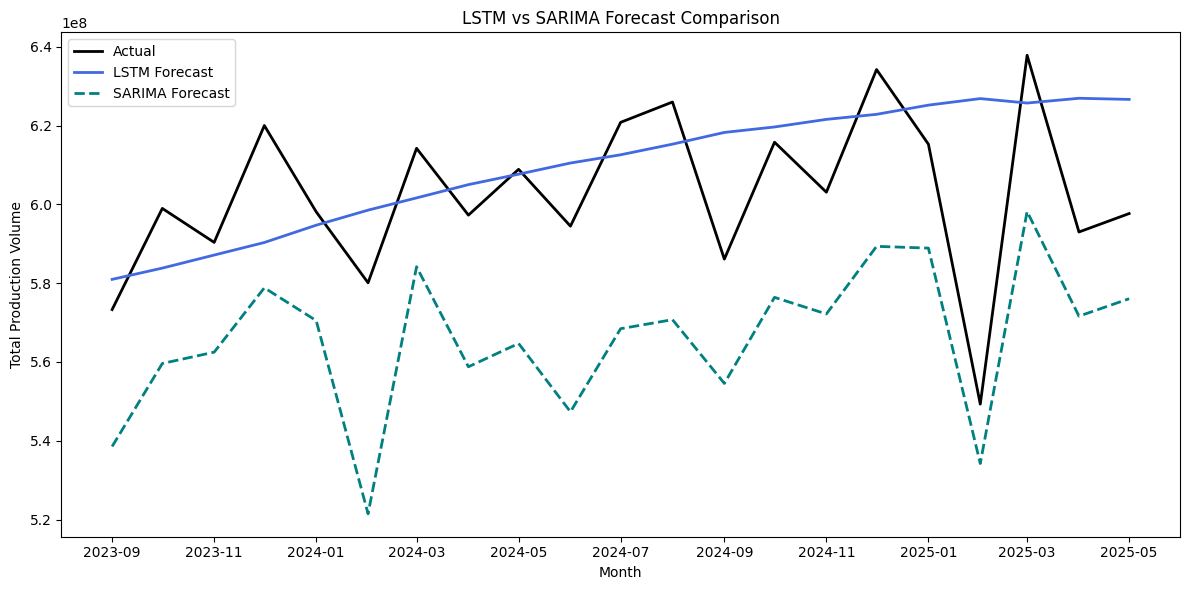

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ensure SARIMA predictions are on log scale
sarima_pred_log = pred_log.values

# LSTM predictions already available
lstm_pred_log = y_pred_log.ravel()
actual_log = y_test_log.ravel()

# Align lengths
min_length = min(len(actual_log), len(lstm_pred_log), len(sarima_pred_log))

actual_log = actual_log[-min_length:]
lstm_pred_log = lstm_pred_log[-min_length:]
sarima_pred_log = sarima_pred_log[-min_length:]

dates = test['Month'].reset_index(drop=True)[-min_length:]

# Convert to original scale for MAPE only
actual_volume = np.expm1(actual_log)
lstm_volume = np.expm1(lstm_pred_log)
sarima_volume = np.expm1(sarima_pred_log)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Month': dates,
    'Actual': actual_volume,
    'LSTM_Predicted': lstm_volume,
    'SARIMA_Predicted': sarima_volume
})

# Log scale metrics
lstm_rmse_log = np.sqrt(mean_squared_error(actual_log, lstm_pred_log))
lstm_mae_log = mean_absolute_error(actual_log, lstm_pred_log)

sarima_rmse_log = np.sqrt(mean_squared_error(actual_log, sarima_pred_log))
sarima_mae_log = mean_absolute_error(actual_log, sarima_pred_log)

# MAPE and Accuracy
lstm_mape = np.mean(np.abs((actual_volume - lstm_volume) /
                           np.clip(np.abs(actual_volume), 1e-8, None))) * 100
sarima_mape = np.mean(np.abs((actual_volume - sarima_volume) /
                             np.clip(np.abs(actual_volume), 1e-8, None))) * 100

lstm_accuracy = 100 - lstm_mape
sarima_accuracy = 100 - sarima_mape

# Print comparison
print("\nModel Performance Comparison")
print(f"{'Metric':<15}{'LSTM':>15}{'SARIMA':>15}")
print("-" * 45)
print(f"{'RMSE':<15}{lstm_rmse_log:>15.4f}{sarima_rmse_log:>15.4f}")
print(f"{'MAE':<15}{lstm_mae_log:>15.4f}{sarima_mae_log:>15.4f}")
print(f"{'MAPE (%)':<15}{lstm_mape:>15.2f}{sarima_mape:>15.2f}")
print(f"{'Accuracy (%)':<15}{lstm_accuracy:>15.2f}{sarima_accuracy:>15.2f}")

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(comparison_df['Month'], comparison_df['Actual'], label='Actual', color='black', linewidth=2)
plt.plot(comparison_df['Month'], comparison_df['LSTM_Predicted'], label='LSTM Forecast', color='royalblue', linewidth=2)
plt.plot(comparison_df['Month'], comparison_df['SARIMA_Predicted'], label='SARIMA Forecast', color='teal', linestyle='--', linewidth=2)
plt.xlabel('Month')
plt.ylabel('Total Production Volume')
plt.title('LSTM vs SARIMA Forecast Comparison')
plt.legend()
plt.tight_layout()
plt.show()